<a href="https://colab.research.google.com/github/muskan524/eshoping/blob/master/mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# libraries


In [ ]:
!pip install torch
!pip install pytorch-tabnet
!pip install shap

In [ ]:
import pandas as pd
import numpy as np
import torch
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from  imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
# from pytorch_tabnet.tab_model import TabNetClassifier

from sklearn.ensemble import VotingClassifier
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    confusion_matrix, precision_recall_curve,
    average_precision_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


# preprocessing


In [ ]:


df = pd.read_csv("drive/MyDrive/ data/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [ ]:
df.shape



(284807, 31)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
print(df["Class"].value_counts())
#fraudulent transaction(0) = 492
#non-fraudulent transaction = 284315

Class
0    284315
1       492
Name: count, dtype: int64


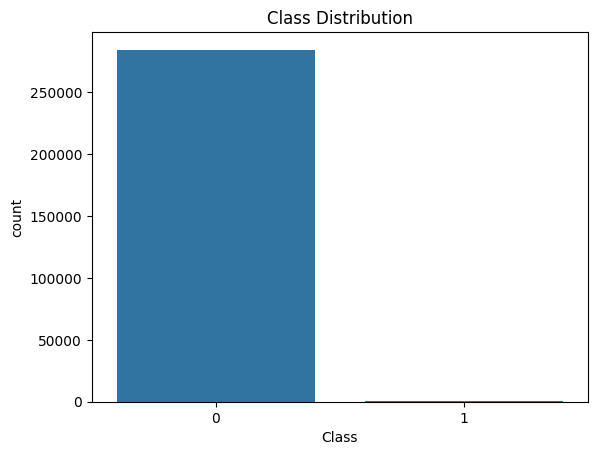

In [ ]:

sns.countplot(x="Class", data=df)
plt.title("Class Distribution")
plt.show()

In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

In [ ]:
# for balance the imbalance data use SMOTE
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp)
print("Training shape" , X_train.shape)
print("testing shape" , X_test.shape)
print("validation shape" , X_val.shape)
print("validation shape" , y_val.shape)
print("testing shape" , y_train.shape)
print("testing shape" , y_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

Training shape (199364, 30)
testing shape (42722, 30)
validation shape (42721, 30)
validation shape (42721,)
testing shape (199364,)
testing shape (42722,)
Class
0    199020
1       344
Name: count, dtype: int64
Class
0    42648
1       74
Name: count, dtype: int64


# Handle imbalance data


In [ ]:
# Handle imbalance data


sm = SMOTE(random_state=SEED, k_neighbors=5)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train, y_train)

print("\nAfter SMOTE (training only):")
print(f"  Train → {X_train_balanced.shape[0]:>7,} | Fraud: {y_train_balanced.sum()} ({y_train_balanced.mean()*100:.1f}%)")
print("Balanced training shape:" , X_train_balanced.shape)
print("Balanced training shape:" , y_train_balanced.shape)
# Convert to numpy for model inputs
X_train_np = X_train_balanced.values if hasattr(X_train_balanced, 'values') else X_train_balanced
y_train_np = y_train_balanced.values if hasattr(y_train_balanced, 'values') else y_train_balanced
X_val_np   = X_val.values
y_val_np  = y_val.values
X_test_np  = X_test.values
y_test_np = y_test.values


After SMOTE (training only):
  Train → 398,040 | Fraud: 199020 (50.0%)
Balanced training shape: (398040, 30)
Balanced training shape: (398040,)


# Scaling


In [ ]:
# feature scaling of only Time and Amount because
# PCA features V1–V28 are already scaled
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_np)

X_test_scaled = scaler.transform(X_test_np)

X_val_scaled = scaler.transform(X_val_np)






In [ ]:
import numpy as np

np.save("X_train_scaled.npy", X_train_scaled)
np.save("X_test_scaled.npy", X_test_scaled)
np.save("X_val_scaled.npy", X_val_scaled)

In [ ]:
import numpy as np
X_train_scaled = np.load("X_train_scaled.npy")
X_test_scaled = np.load("X_test_scaled.npy")
X_val_scaled = np.load("X_val_scaled.npy")

In [ ]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.to_csv("scaled_data.csv", index=False)
X_scaled_df.to_excel("scaled_data.xlsx", index=False)
np.save("scaled_data.npy", X_scaled)

NameError: name 'X_scaled' is not defined

# Build XGBoost Model


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
# XGBoost model
xgb_model = XGBClassifier(
    n_estimators=1200,
    max_depth=6,
    learning_rate=0.02,
    min_child_weight=3,#tuning 1 to 3 to better precission
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",

    random_state=42,
    eval_metric="aucpr",
    # early_stopping_rounds=50,
    tree_method = 'hist'

)
xgb_model.fit(
    X_train_scaled,
    y_train_np,
    eval_set=[(X_val_scaled, y_val_np)],
    verbose=100
)
# Evaluating xgb
def evaluate_model(model, X_test, y_test, model_name):

    # Step 1 — get probabilities
    y_proba = model.predict_proba(X_test)[:, 1]

    # Step 2 — set threshold
    threshold = 0.55

    # Step 3 — convert probability to class
    y_pred = (y_proba >= threshold).astype(int)

    print("\n", model_name)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
# evalute
evaluate_model(
  xgb_model,
  X_test_scaled,
  y_test_np,
  "XGBoost"
  )

[0]	validation_0-aucpr:0.34478
[100]	validation_0-aucpr:0.68194
[200]	validation_0-aucpr:0.74199
[300]	validation_0-aucpr:0.77411
[400]	validation_0-aucpr:0.77654
[500]	validation_0-aucpr:0.78893
[600]	validation_0-aucpr:0.79478
[700]	validation_0-aucpr:0.80014
[800]	validation_0-aucpr:0.80064
[900]	validation_0-aucpr:0.80245
[1000]	validation_0-aucpr:0.80239
[1100]	validation_0-aucpr:0.80302
[1199]	validation_0-aucpr:0.80276

 XGBoost
Accuracy: 0.9995084499789336
Precision: 0.8533333333333334
Recall: 0.8648648648648649
F1: 0.8590604026845637
ROC-AUC: 0.9885384822075874


In [ ]:
# Evaluating LightGBM
def evaluate_model(model, X_test, y_test, model_name):

    # Step 1 — get probabilities
    y_proba = model.predict_proba(X_test)[:, 1]

    # Step 2 — set threshold
    threshold = 0.55

    # Step 3 — convert probability to class
    y_pred = (y_proba >= threshold).astype(int)

    print("\n", model_name)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
# evalute
evaluate_model(
  xgb_model,
  X_test_scaled,
  y_test_np,
  "XGboost"
  )


 XGboost
Accuracy: 0.9995084499789336
Precision: 0.8533333333333334
Recall: 0.8648648648648649
F1: 0.8590604026845637
ROC-AUC: 0.9885384822075874


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
# Evaluate XGBoost model with threshhold 0.55
def evaluate_model(model, X_test_scaled, y_test_np, model_name):

    # Step 1 — get probabilities
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Step 2 — set threshold
    threshold = 0.55

    # Step 3 — convert probability to class
    y_pred = (y_proba >= threshold).astype(int)

    print("\n", model_name)

    print("Accuracy:", accuracy_score(y_test_np, y_pred))
    print("Precision:", precision_score(y_test_np, y_pred))
    print("Recall:", recall_score(y_test_np, y_pred))
    print("F1:", f1_score(y_test_np, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test_np, y_proba))
    # evalute xgboost model

evaluate_model(
  xgb_model,
  X_test_scaled,
  y_test_np,
  "XGBoost"
  )



NotFittedError: need to call fit or load_model beforehand

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Model
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# Parameter grid
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(
    X_train_scaled,
    y_train_balanced
)

print("Best Parameters:")
print(grid_search.best_params_)

print("Best Score:")
print(grid_search.best_score_)

Fitting 3 folds for each of 72 candidates, totalling 216 fits


KeyboardInterrupt: 

In [ ]:
# XGBoost model
xgb_model = XGBClassifier(
    n_estimators=1200,
    max_depth=6,
    learning_rate=0.02,
    min_child_weight=3,#tuning 1 to 3 to better precission
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    # scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="aucpr",
    # early_stopping_rounds=50,
    tree_method = 'hist'

)
xgb_model.fit(
    X_train_scaled,
    y_train_np,
    eval_set=[(X_val_scaled, y_val_np)],
    verbose=100
)

[0]	validation_0-aucpr:0.34478


KeyboardInterrupt: 

#  Lightboost model


In [ ]:
(y_train_np == 1).sum()
# y_train_np.shape
# y_train_np.sha

np.int64(199020)

In [ ]:
# LightBoost model
lgb_model = LGBMClassifier(

    n_estimators=1200,
    learning_rate=0.02,
    num_leaves=31, #31 to 63
    max_depth=6,
    min_child_samples=20, #20 to 30
    min_child_weight=1,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.3,
    reg_lambda=3,
    objective="binary",

    random_state=42,
    n_jobs=-1
)

# lgb_model.fit(
#     X_train_scaled,
#     y_train_balanced
# )
lgb_model.fit(
    X_train_scaled,
    y_train_np,
    eval_set=[(X_val_scaled, y_val_np)],
    eval_metric="auc",
)


[LightGBM] [Info] Number of positive: 199020, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.252517 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 398040, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.02, max_depth=6,
               min_child_weight=1, n_estimators=1200, n_jobs=-1,
               objective='binary', random_state=42, reg_alpha=0.3, reg_lambda=3,
               subsample=0.8)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
# Evaluating LightGBM
def evaluate_model(model, X_test, y_test, model_name):

    # Step 1 — get probabilities
    y_proba = model.predict_proba(X_test)[:, 1]

    # Step 2 — set threshold
    threshold = 0.5

    # Step 3 — convert probability to class
    y_pred = (y_proba >= threshold).astype(int)

    print("\n", model_name)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
# evalute
evaluate_model(
  lgb_model,
  X_test_scaled,
  y_test_np,
  "LightGBM"
  )


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



 LightGBM
Accuracy: 0.9993914142596321
Precision: 0.8
Recall: 0.8648648648648649
F1: 0.8311688311688312
ROC-AUC: 0.9884963396147977


# Build decision tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(

    max_depth=4,
    min_samples_split=50,
    min_samples_leaf=30,
    class_weight="balanced",
    random_state=42
)

dt_model.fit(
    X_train_scaled,
    y_train_np
)

DecisionTreeClassifier(class_weight='balanced', max_depth=4,
                       min_samples_leaf=30, min_samples_split=50,
                       random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
def evaluate_model(model, X_test, y_test, threshold):

    probs = model.predict_proba(X_test)[:, 1]

    preds = (probs >= threshold).astype(int)

    print("\nDecision Tree")

    print("Accuracy:", accuracy_score(y_test, preds))
    print("Precision:", precision_score(y_test, preds))
    print("Recall:", recall_score(y_test, preds))
    print("F1:", f1_score(y_test, preds))
    print("ROC-AUC:", roc_auc_score(y_test, probs))


# Use your threshold (example: 0.9 or 0.95)

evaluate_model(
    dt_model,
    X_test_scaled,
    y_test,
    threshold=0.95
)


Decision Tree
Accuracy: 0.9912223210523852
Precision: 0.14918414918414918
Recall: 0.8648648648648649
F1: 0.2544731610337972
ROC-AUC: 0.9655720365835728


# build logistic regression


In [ ]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(
    solver="liblinear",     # better for imbalanced data
    C=0.2,
    penalty="l1",

    max_iter=2000,
    class_weight=None,
    random_state=42
)

lr_model.fit(
    X_train_scaled,
    y_train_balanced
)

print("Logistic Regression trained")
def evaluate_model(model, X_test, y_test, threshold):

    probs = model.predict_proba(X_test)[:, 1]

    preds = (probs >= threshold).astype(int)

    print("\nLogistic Regression")

    print("Accuracy:", accuracy_score(y_test, preds))
    print("Precision:", precision_score(y_test, preds))
    print("Recall:", recall_score(y_test, preds))
    print("F1:", f1_score(y_test, preds))
    print("ROC-AUC:", roc_auc_score(y_test, probs))


# Use your chosen threshold (example: 0.9)

evaluate_model(
    lr_model,
    X_test_scaled,
    y_test,
    threshold=0.97
)

Logistic Regression trained

Logistic Regression
Accuracy: 0.9989700856701466
Precision: 0.6530612244897959
Recall: 0.8648648648648649
F1: 0.7441860465116279
ROC-AUC: 0.9739496988547354


#Ensemble model

In [ ]:
# build ensemble model
from sklearn.ensemble import VotingClassifier

ensemble_model = VotingClassifier(

    estimators=[
        ("xgb", xgb_model),
        ("lgb", lgb_model)
    ],

    voting="soft",

    # LightGBM slightly stronger → higher weight
    weights=[2, 1],

    n_jobs=-1
)

ensemble_model.fit(
    X_train_scaled,
    y_train_np
)


VotingClassifier(estimators=[('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.8, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='aucpr',
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_const...
                                            missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=1200, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('lgb',
                              LGBMClassifier(colsample_bytree=0.8,
                                             learning_rate=0.02, max_depth=6,
                                             min_child_weight=1,
                                             n_estimators=1200, n_jobs=-1,
                                             objective='binary',
                                             random_state=42, reg_alpha=0.3,
                                             reg_lambda=3, subsample=0.8))],
                 n_jobs=-1, voting='soft', weights=[1, 2])

In [ ]:
#evaluate ensemble model
def evaluate_model(model, X_test, y_test, model_name):

    # Step 1 — get probabilities
    y_proba = model.predict_proba(X_test)[:, 1]

    # Step 2 — set threshold
    threshold = 0.9

    # Step 3 — convert probability to class
    y_pred = (y_proba >= threshold).astype(int)

    print("\n", model_name)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
# evalute
evaluate_model(
  ensemble_model,
  X_test_scaled,
  y_test_np,
  "Ensemble model"
  )


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



 Ensemble model
Accuracy: 0.9995552642666542
Precision: 0.9230769230769231
Recall: 0.8108108108108109
F1: 0.8633093525179856
ROC-AUC: 0.9922413268642869


In [ ]:
print("=" * 55)
print("TRAINING TabNet")
print("=" * 55)
print(f"Device: {device}")

# Sample weights — fraud samples weighted higher so TabNet
# focuses more on learning the rare fraud pattern
class_counts  = np.bincount(y_train_np.astype(int))
class_weights = len(y_train_np) / (2 * class_counts)
sample_weights = class_weights[y_train_np.astype(int)]

tabnet_model = TabNetClassifier(
    n_d             = 32,    # Width of decision step output
    n_a             = 32,    # Width of attention embedding
    n_steps         = 5,     # Number of sequential attention steps
    gamma           = 1.3,   # Sparsity: higher = fewer features per step
    n_independent   = 2,     # Independent GLU layers per step
    n_shared        = 2,     # Shared GLU layers across all steps
    momentum        = 0.02,
    epsilon         = 1e-15,
    seed            = SEED,
    device_name     = device,
    verbose         = 1
)

tabnet_model.fit(
    X_train_np, y_train_np,
    eval_set           = [(X_val_np, y_val_np)],
    eval_metric        = ['auc'],
    max_epochs         = 100,
    patience           = 15,    # Early stopping: stop after 15 bad epochs
    batch_size         = 1024,
    virtual_batch_size = 128,   # Ghost Batch Normalization size
    weights            = sample_weights
)

tab_val_auc = roc_auc_score(y_val_np, tabnet_model.predict_proba(X_val_np)[:,1])
print(f"\n✅ TabNet done | Val AUC: {tab_val_auc:.4f}")

TRAINING TabNet


NameError: name 'device' is not defined

#  Tabnet

In [ ]:
(y_train_np == 1).sum()

np.int64(199020)

In [ ]:

from pytorch_tabnet.tab_model import TabNetClassifier

import torch
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ==============================
# Train TabNet
# ==============================

tabnet_model = TabNetClassifier(
    n_d=32,
    n_a=32,
    n_steps=5,
    gamma=1.5,
    lambda_sparse=5e-4,

    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-3),  # lower learning rate

    scheduler_params={
        "step_size": 20,
        "gamma": 0.9
    },
    scheduler_fn=torch.optim.lr_scheduler.StepLR,

    seed=42,
    verbose=1
)
tabnet_model.fit(
    X_train_scaled,
    y_train_np,

    eval_set=[(X_test_scaled, y_test_np)],
    eval_metric=["auc"],

    max_epochs=100,
    patience=15,

    batch_size=4096,
    virtual_batch_size=512,

    num_workers=0,
    drop_last=False
)

print("TabNet trained")


# ==============================
# Evaluate Model
# ==============================

def evaluate_model(model, X_test_scaled, y_test_np, threshold):

    probs = model.predict_proba(X_test_scaled)[:, 1]

    preds = (probs >= threshold).astype(int)

    print("\nTabNet")

    print("Accuracy:", accuracy_score(y_test_np, preds))
    print("Precision:", precision_score(y_test_np, preds))
    print("Recall:", recall_score(y_test_np, preds))
    print("F1:", f1_score(y_test, preds))
    print("ROC-AUC:", roc_auc_score(y_test_np, probs))


# Use your threshold (example)



/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.29643 | val_0_auc: 0.96262 |  0:00:43s
epoch 1  | loss: 0.0886  | val_0_auc: 0.9732  |  0:01:23s
epoch 2  | loss: 0.06218 | val_0_auc: 0.96852 |  0:02:04s
epoch 3  | loss: 0.04907 | val_0_auc: 0.97243 |  0:02:44s
epoch 4  | loss: 0.03927 | val_0_auc: 0.98362 |  0:03:24s
epoch 5  | loss: 0.03467 | val_0_auc: 0.96799 |  0:04:05s
epoch 6  | loss: 0.03177 | val_0_auc: 0.96562 |  0:04:43s
epoch 7  | loss: 0.03017 | val_0_auc: 0.96781 |  0:05:22s
epoch 8  | loss: 0.02819 | val_0_auc: 0.97104 |  0:06:01s
epoch 9  | loss: 0.02563 | val_0_auc: 0.96799 |  0:06:42s
epoch 10 | loss: 0.0212  | val_0_auc: 0.96224 |  0:07:21s
epoch 11 | loss: 0.01862 | val_0_auc: 0.96774 |  0:07:59s
epoch 12 | loss: 0.0177  | val_0_auc: 0.97444 |  0:08:37s
epoch 13 | loss: 0.01616 | val_0_auc: 0.95792 |  0:09:16s
epoch 14 | loss: 0.01514 | val_0_auc: 0.96596 |  0:09:55s
epoch 15 | loss: 0.0137  | val_0_auc: 0.96517 |  0:10:34s
epoch 16 | loss: 0.01363 | val_0_auc: 0.97042 |  0:11:13s
epoch 17 | los

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


TabNet trained


In [ ]:
# threshold tuning
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

probs = tabnet_model.predict_proba(X_test_scaled)[:, 1]

thresholds = np.arange(0.9, 1.0, 0.01)

for t in thresholds:
    preds = (probs >= t).astype(int)

    precision = precision_score(y_test_np, preds)
    recall = recall_score(y_test_np, preds)
    f1 = f1_score(y_test_np, preds)

    print(
        f"Threshold: {t:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.90 | Precision: 0.272 | Recall: 0.851 | F1: 0.412
Threshold: 0.91 | Precision: 0.285 | Recall: 0.851 | F1: 0.427
Threshold: 0.92 | Precision: 0.310 | Recall: 0.851 | F1: 0.455
Threshold: 0.93 | Precision: 0.335 | Recall: 0.838 | F1: 0.479
Threshold: 0.94 | Precision: 0.353 | Recall: 0.824 | F1: 0.494
Threshold: 0.95 | Precision: 0.374 | Recall: 0.824 | F1: 0.515
Threshold: 0.96 | Precision: 0.396 | Recall: 0.824 | F1: 0.535
Threshold: 0.97 | Precision: 0.433 | Recall: 0.824 | F1: 0.567
Threshold: 0.98 | Precision: 0.500 | Recall: 0.797 | F1: 0.615
Threshold: 0.99 | Precision: 0.596 | Recall: 0.797 | F1: 0.682


In [ ]:
def evaluate_model(model, X_test_scaled, y_test_np, threshold):

    probs = model.predict_proba(X_test_scaled)[:, 1]

    preds = (probs >= threshold).astype(int)

    print("\nTabNet")

    print("Accuracy:", accuracy_score(y_test_np, preds))
    print("Precision:", precision_score(y_test_np, preds))
    print("Recall:", recall_score(y_test_np, preds))
    print("F1:", f1_score(y_test, preds))
    print("ROC-AUC:", roc_auc_score(y_test_np, probs))


In [ ]:
evaluate_model(
    tabnet_model,
    X_test_scaled,
    y_test_np,
    threshold=0.99
)


TabNet
Accuracy: 0.9987126070876832
Precision: 0.5959595959595959
Recall: 0.7972972972972973
F1: 0.6820809248554913
ROC-AUC: 0.9836169878375844


In [ ]:
proba_output = tabnet_model.predict_proba(X_test.values)

print(type(proba_output))
print(proba_output.shape)

<class 'numpy.ndarray'>
(42722, 2)


In [ ]:
from sklearn.metrics import confusion_matrix

probs = tabnet_model.predict_proba(X_test_np)[:, 1]

y_pred= (probs >= 0.999).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test_np, y_pred)

# Extract values
TN, FP, FN, TP = cm.ravel()

print("Confusion Matrix:")
print(cm)

print("\n--- Fraud Detection Summary ---")

# Total actual fraud cases in test data
actual_fraud = (y_test_np == 1).sum()
print("Actual Fraud Cases in Test Data:", actual_fraud)

# Total predicted fraud cases
predicted_fraud = (y_pred == 1).sum()
print("Predicted Fraud Cases:", predicted_fraud)

# Correctly detected fraud cases
print("Correctly Detected Fraud Cases (TP):", TP)

# False Negatives (missed fraud cases)
print("False Negatives (FN):", FN)

# Detection Rate (Recall)
detection_rate = TP / (TP + FN)
print("Detection Rate (Recall):", detection_rate)

# False Negative Rate
false_negative_rate = FN / (TP + FN)
print("False Negative Rate:", false_negative_rate)

Confusion Matrix:
[[39581  3067]
 [   14    60]]

--- Fraud Detection Summary ---
Actual Fraud Cases in Test Data: 74
Predicted Fraud Cases: 3127
Correctly Detected Fraud Cases (TP): 60
False Negatives (FN): 14
Detection Rate (Recall): 0.8108108108108109
False Negative Rate: 0.1891891891891892


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

weights = {
    0: class_weights[0],
}


In [ ]:
tabnet_model = TabNetClassifier(
    n_d=32,
    n_a=32,
    n_steps=5,
    gamma=1.5,
    lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.001),
    seed=42,
    verbose=1
)

tabnet_model.fit(
    X_train_balanced.values,
    y_train_balanced.values,
    eval_set=[(X_test_scaled, y_test.values)],
    eval_metric=["auc"],
    max_epochs=100,
    patience=20,
    batch_size=1024,
    virtual_batch_size=128
)

In [ ]:
# Install if not already installed
# !pip install pytorch-tabnet

import numpy as np
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Convert data to numpy (TabNet requires numpy arrays)
X_train_np = X_train_scaled.values
X_test_np = X_test_scaled.values

y_train_np = y_train_balanced.values
y_test_np = y_test.values

# Initialize TabNet model
tabnet_model = TabNetClassifier(
    n_d=16, n_a=16,
    n_steps=5,
    gamma=1.5,
    lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size":50, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    verbose=1,
    seed=42
)

# Train the model
tabnet_model.fit(
    X_train_np, y_train_np,
    eval_set=[(X_test_np, y_test_np)],
    eval_name=['validation'],
    eval_metric=['auc'],
    max_epochs=50,
    patience=10,
    batch_size=1024,
    virtual_batch_size=128
)

# Predictions
y_pred = tabnet_model.predict(X_test_np)
y_proba = tabnet_model.predict_proba(X_test_np)[:, 1]

# Evaluation
print("TabNet Performance:\n")

print("Accuracy:", accuracy_score(y_test_np, y_pred))
print("Precision:", precision_score(y_test_np, y_pred))
print("Recall:", recall_score(y_test_np, y_pred))
print("F1 Score:", f1_score(y_test_np, y_pred))
print("ROC-AUC:", roc_auc_score(y_test_np, y_proba))

AttributeError: 'numpy.ndarray' object has no attribute 'values'

NEW


In [ ]:

from pytorch_tabnet.tab_model import TabNetClassifier

import torch
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ==============================
# Train TabNet
# ==============================

tabnet_model = TabNetClassifier(
    n_d=32,
    n_a=32,
    n_steps=7,
    gamma=1.5,
    lambda_sparse=1e-3,

    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=1e-3),  # lower learning rate

    scheduler_params={
        "step_size": 20,
        "gamma": 0.9
    },
    scheduler_fn=torch.optim.lr_scheduler.StepLR,

    seed=42,
    verbose=1
)
tabnet_model.fit(
    X_train_scaled,
    y_train_np,

    eval_set=[(X_test_scaled, y_test_np)],
    eval_metric=["auc"],

    max_epochs=100,
    patience=15,

    batch_size=4096,
    virtual_batch_size=512,

    num_workers=0,
    drop_last=False
)

print("TabNet trained")


# ==============================
# Evaluate Model
# ==============================

def evaluate_model(model, X_test_scaled, y_test_np, threshold):

    probs = model.predict_proba(X_test_scaled)[:, 1]

    preds = (probs >= threshold).astype(int)

    print("\nTabNet")

    print("Accuracy:", accuracy_score(y_test_np, preds))
    print("Precision:", precision_score(y_test_np, preds))
    print("Recall:", recall_score(y_test_np, preds))
    print("F1:", f1_score(y_test, preds))
    print("ROC-AUC:", roc_auc_score(y_test_np, probs))



/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.63038 | val_0_auc: 0.89774 |  0:00:57s
epoch 1  | loss: 0.2163  | val_0_auc: 0.94272 |  0:01:51s
epoch 2  | loss: 0.15303 | val_0_auc: 0.9469  |  0:02:48s
epoch 3  | loss: 0.12444 | val_0_auc: 0.96379 |  0:03:41s
epoch 4  | loss: 0.11719 | val_0_auc: 0.96912 |  0:04:35s
epoch 5  | loss: 0.10284 | val_0_auc: 0.95715 |  0:05:28s
epoch 6  | loss: 0.09123 | val_0_auc: 0.9655  |  0:06:23s
epoch 7  | loss: 0.08119 | val_0_auc: 0.96127 |  0:07:19s
epoch 8  | loss: 0.07854 | val_0_auc: 0.974   |  0:08:15s
epoch 9  | loss: 0.07494 | val_0_auc: 0.96987 |  0:09:08s
epoch 10 | loss: 0.07177 | val_0_auc: 0.97609 |  0:10:04s
epoch 11 | loss: 0.06794 | val_0_auc: 0.97491 |  0:10:59s
epoch 12 | loss: 0.06541 | val_0_auc: 0.96877 |  0:11:52s
epoch 13 | loss: 0.06365 | val_0_auc: 0.94937 |  0:12:44s
epoch 14 | loss: 0.05897 | val_0_auc: 0.95168 |  0:13:37s
epoch 15 | loss: 0.05619 | val_0_auc: 0.95601 |  0:14:30s
epoch 16 | loss: 0.05188 | val_0_auc: 0.95837 |  0:15:22s
epoch 17 | los

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


TabNet trained


In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

probs = tabnet_model.predict_proba(X_test_scaled)[:, 1]

thresholds = np.linspace(0.5, 0.999, 50)

best_precision = 0
best_threshold = 0
best_recall = 0

for t in thresholds:
    preds = (probs >= t).astype(int)
    precision = precision_score(y_test_np, preds)
    recall = recall_score(y_test_np, preds)
    f1 = f1_score(y_test_np, preds)

    if precision > best_precision:
        best_precision = precision
        best_threshold = t

    if recall > best_recall:
        best_recall = recall
        best_threshold = t


print("Best Threshold:", best_threshold)
print("Best Precision:", best_precision)
print("Best recall :", best_recall)
print("f1 score:",f1)

Best Threshold: 0.999
Best Precision: 0.734375
Best recall : 0.8783783783783784
f1 score: 0.6811594202898551


In [ ]:
import numpy as np
from sklearn.metrics import recall_score

probs = tabnet_model.predict_proba(X_test_scaled)[:, 1]

thresholds = np.linspace(0.1, 0.99, 50)

best_recall = 0
best_threshold = 0

for t in thresholds:
    preds = (probs >= t).astype(int)
    recall = recall_score(y_test_np, preds)

    if recall > best_recall:
        best_recall = recall
        best_threshold = t

print("Best Threshold for Recall:", best_threshold)
print("Best Recall:", best_recall)

Best Threshold for Recall: 0.1
Best Recall: 0.8918918918918919


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Get probabilities again (or reuse)
probs = tabnet_model.predict_proba(X_test_scaled)[:, 1]

# Apply best threshold
final_preds = (probs >= best_threshold).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test_np, final_preds)
precision = precision_score(y_test_np, final_preds)
recall = recall_score(y_test_np, final_preds)
f1 = f1_score(y_test_np, final_preds)
roc_auc = roc_auc_score(y_test_np, probs)

# Confusion Matrix
TN, FP, FN, TP = confusion_matrix(y_test_np, final_preds).ravel()

# Print results
print("\nFinal Evaluation using Best Threshold:\n")

print("Threshold:", best_threshold)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)

print("\nConfusion Matri   x:")
print("TP:", TP)
print("FP:", FP)
print("FN:", FN)
print("TN:", TN)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Predictions
probs = model.predict_proba(X_test_scaled)[:, 1]
preds = (probs >= 0.5).astype(int)

# Metrics
print("Accuracy:", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall:", recall_score(y_test, preds))
print("F1 Score:", f1_score(y_test, preds))
print("ROC-AUC:", roc_auc_score(y_test, probs))

# Confusion Matrix
cm = confusion_matrix(y_test, preds)
print("\nConfusion Matrix:\n", cm)

NameError: name 'model' is not defined

# Evaluation

# XAI


/tmp/ipykernel_68208/1361305492.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


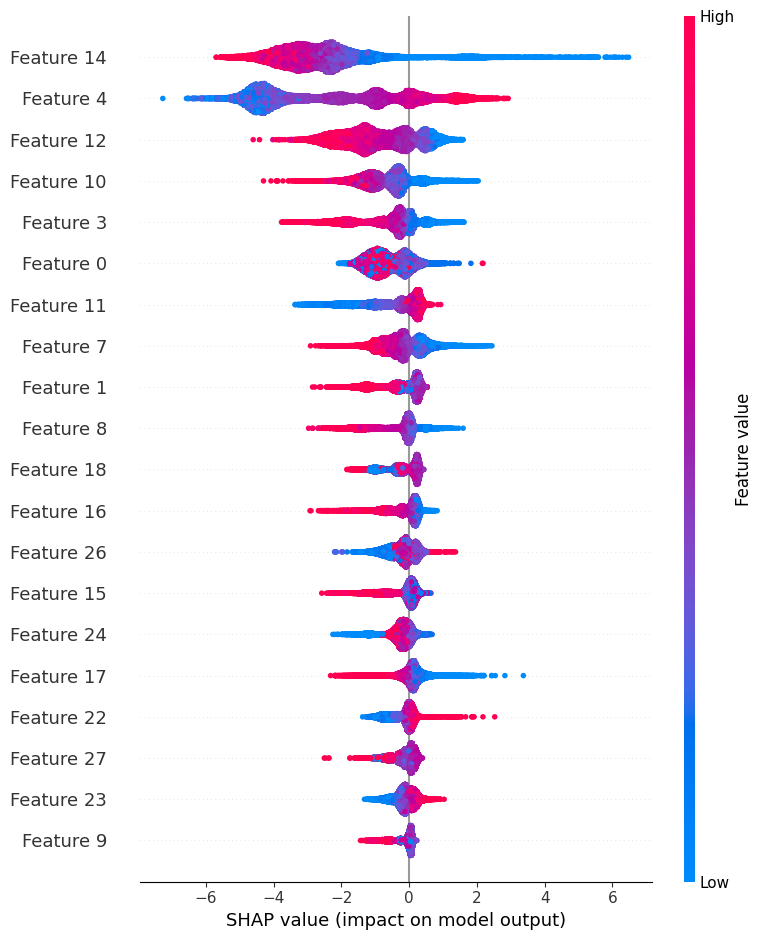

In [ ]:
# XAI on XGBOOST
from xgboost import XGBClassifier
# Create explainer
explainer_xgb = shap.TreeExplainer(xgb_model)

# Calculate SHAP values
shap_values_xgb = explainer_xgb.shap_values(X_test_scaled)

# Plot feature importance
shap.summary_plot(
    shap_values_xgb,
    X_test_scaled
)


In [ ]:
import seaborn
explainer_xgb = shap.TreeExplainer(xgb_model)

shap_values_xgb = explainer_xgb(X_test_scaled)


# Calculate SHAP values
# shap_values_xgb = explainer_xgb.shap_values(X_test_scaled)

# Plot summary plot
shap.summary_plot(
    shap_values_xgb,
    X_test_scaled,
    max_display=20
)

NameError: name 'xgb_model' is not defined

In [ ]:
# Calculate mean absolute SHAP value
shap_importance = np.abs(shap_values_xgb).mean(axis=0)

# Create DataFrame
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'SHAP Importance': shap_importance
})

# Sort features
feature_importance = feature_importance.sort_values(
    by='SHAP Importance',
    ascending=False
)
top_20_features = feature_importance.head(20)

print(top_20_features)

   Feature  SHAP Importance
14     V14         2.753971
4       V4         2.614409
12     V12         1.107054
10     V10         0.779174
3       V3         0.677016
0     Time         0.676806
11     V11         0.624201
7       V7         0.490271
1       V1         0.443515
8       V8         0.430804
18     V18         0.348212
16     V16         0.329645
26     V26         0.323756
15     V15         0.299794
24     V24         0.272266
17     V17         0.264267
22     V22         0.262320
27     V27         0.236161
23     V23         0.234601
9       V9         0.182376


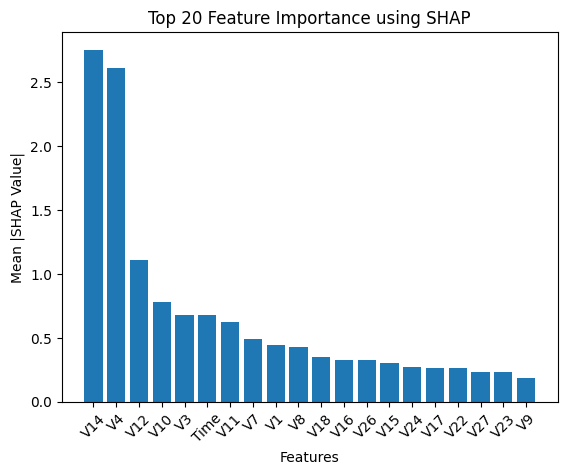

In [ ]:
import matplotlib.pyplot as plt

# Plot bar graph
plt.figure()
plt.bar(
    top_20_features["Feature"],
    top_20_features["SHAP Importance"]
)

plt.title("Top 20 Feature Importance using SHAP")
plt.xlabel("Features")
plt.ylabel("Mean |SHAP Value|")

plt.xticks(rotation=45)

plt.show()

XAI for lightgbm


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/tmp/ipykernel_68208/4152401009.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


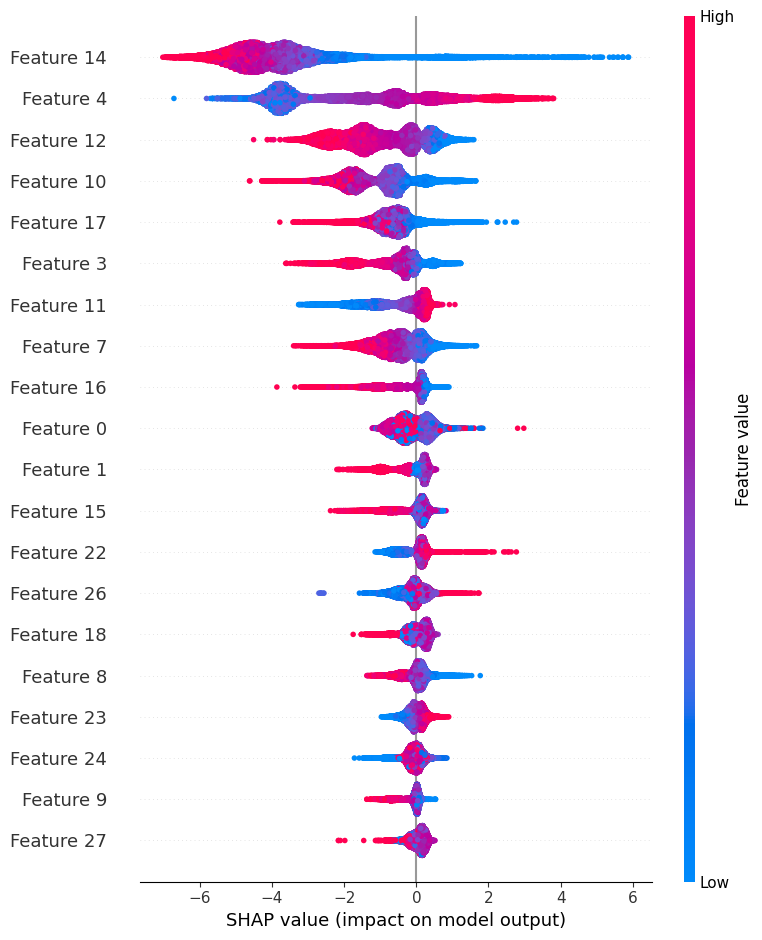

In [ ]:
# XAI on LightGBm
# from xgboost import LGBClassifier
# Create explainer
explainer_lgb = shap.TreeExplainer(lgb_model)

# Calculate SHAP values
shap_values_lgb = explainer_lgb.shap_values(X_test_scaled)

# Plot feature importance
shap.summary_plot(
    shap_values_lgb,
    X_test_scaled
)

In [ ]:
# Calculate mean absolute SHAP value
shap_importance = np.abs(shap_values_lgb).mean(axis=0)

# Create DataFrame
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'SHAP Importance': shap_importance
})

# Sort features
feature_importance = feature_importance.sort_values(
    by='SHAP Importance',
    ascending=False
)
top_20_features = feature_importance.head(20)

print(top_20_features)

   Feature  SHAP Importance
14     V14         3.944943
4       V4         2.289709
12     V12         1.187335
10     V10         1.173541
17     V17         0.717903
3       V3         0.674853
11     V11         0.616685
7       V7         0.608201
16     V16         0.472222
0     Time         0.373766
1       V1         0.356523
15     V15         0.311432
22     V22         0.275223
26     V26         0.262456
18     V18         0.240974
8       V8         0.234356
23     V23         0.179912
24     V24         0.179107
9       V9         0.169901
27     V27         0.169316


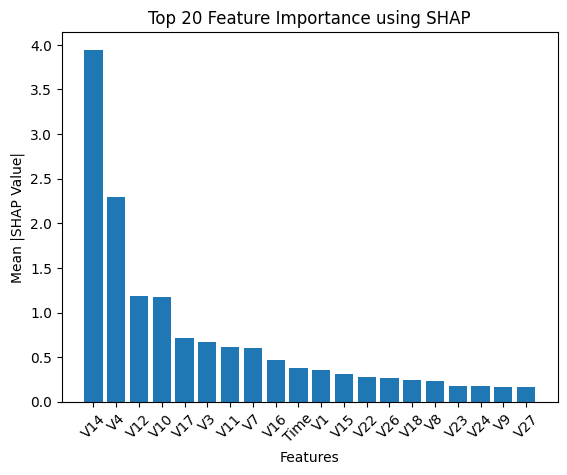

In [ ]:
import matplotlib.pyplot as plt

# Plot bar graph
plt.figure()
plt.bar(
    top_20_features["Feature"],
    top_20_features["SHAP Importance"]
)

plt.title("Top 20 Feature Importance using SHAP")
plt.xlabel("Features")
plt.ylabel("Mean |SHAP Value|")

plt.xticks(rotation=45)

plt.show()

XAI for TABNET


In [ ]:
import pandas as pd

feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': tabnet_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feat_imp.head(20))

   Feature  Importance
14     V14    0.149099
12     V12    0.086752
4       V4    0.075819
6       V6    0.056301
10     V10    0.052808
3       V3    0.049307
11     V11    0.041228
17     V17    0.032329
21     V21    0.031509
7       V7    0.031014
23     V23    0.029603
27     V27    0.029378
8       V8    0.026767
18     V18    0.024851
22     V22    0.024844
15     V15    0.024226
2       V2    0.023985
19     V19    0.022310
5       V5    0.021526
25     V25    0.021022


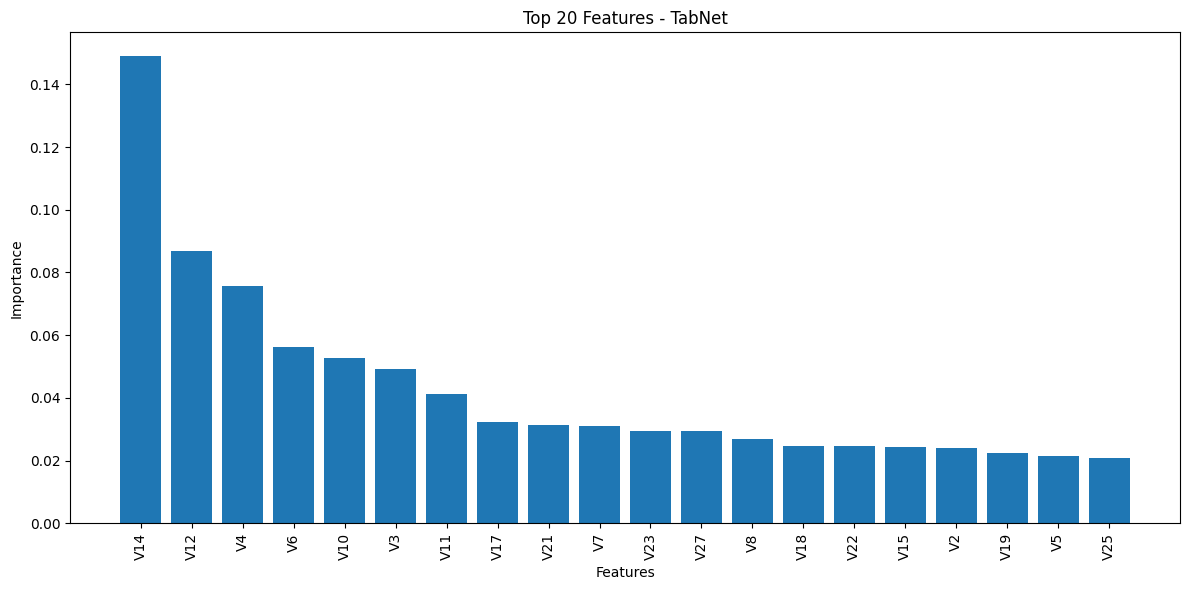

In [ ]:
import matplotlib.pyplot as plt

# Take top 20 features
top20 = feat_imp.head(20)

plt.figure(figsize=(12,6))

plt.bar(top20['Feature'], top20['Importance'])

# Rotate feature names so they don’t overlap
plt.xticks(rotation=90)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Top 20 Features - TabNet")

plt.tight_layout()
plt.show()

In [ ]:
explain_matrix, masks = tabnet_model.explain(X_test)

import matplotlib.pyplot as plt

plt.imshow(masks[0][:50])
plt.title("TabNet Feature Attention (Step 1)")
plt.colorbar()
plt.show()

KeyError: 0

##END


In [ ]:
explain_matrix, masks = tabnet_model.explain(X_test)

import matplotlib.pyplot as plt

plt.imshow(masks[0][:50])
plt.title("TabNet Feature Attention (Step 1)")
plt.colorbar()
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(xgb_model, X_train_scaled, y_train_balanced, cv=5)
print(scores.mean())

0.9998291628982013


In [ ]:
# XAI on LightGB

explainer_lgb = shap.TreeExplainer(lgb_model)

shap_values_lgb = explainer_lgb.shap_values(X_test_scaled)

shap.summary_plot(
    shap_values_lgb,
    X_test_scaled
)

NameError: name 'lgb_model' is not defined

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, average_precision_score)
from imblearn.over_sampling import SMOTE
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

# ── 1. Load data ──────────────────────────────────────────────────────────────
df = pd.read_csv("drive/MyDrive/ data/creditcard.csv")          # download from Kaggle
print(df["Class"].value_counts())           # check severe imbalance

X = df.drop("Class", axis=1).values
y = df["Class"].values

# ── 2. Scale Amount & Time (V1-V28 are already PCA'd) ────────────────────────
scaler = StandardScaler()
X[:, [0, -1]] = scaler.fit_transform(X[:, [0, -1]])   # Time=col0, Amount=col29

# ── 3. Train / val / test split ───────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=42)

# ── 4. Handle class imbalance with SMOTE (only on train set) ─────────────────
sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)
print(f"After SMOTE — Train shape: {X_train.shape}")

# ── 5. Build TabNet model ─────────────────────────────────────────────────────
clf = TabNetClassifier(
    n_d=32,               # width of decision step output (8–64)
    n_a=32,               # width of attention embedding (same as n_d is common)
    n_steps=5,            # number of sequential attention steps
    gamma=1.3,            # sparsity regularisation (higher → sparser masks)
    n_independent=2,      # independent GLU layers in feature transformer
    n_shared=2,           # shared GLU layers in feature transformer
    lambda_sparse=1e-3,   # sparsity loss weight
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-3, weight_decay=1e-5),
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params=dict(step_size=10, gamma=0.9),
    mask_type="sparsemax",  # sparsemax gives harder feature selection than softmax
    verbose=10,
    device_name="auto",   # uses GPU if available
)

# ── 6. Train ──────────────────────────────────────────────────────────────────
clf.fit(
    X_train=X_train, y_train=y_train,
    eval_set=[(X_val, y_val)],
    eval_name=["val"],
    eval_metric=["auc"],
    max_epochs=100,
    patience=20,           # early stopping
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False,
)

# ── 7. Evaluate ───────────────────────────────────────────────────────────────
y_pred      = clf.predict(X_test)
y_pred_prob = clf.predict_proba(X_test)[:, 1]

print("\n── Classification Report ──")
print(classification_report(y_test, y_pred, target_names=["Legit", "Fraud"]))
print(f"ROC-AUC  : {roc_auc_score(y_test, y_pred_prob):.4f}")
print(f"PR-AUC   : {average_precision_score(y_test, y_pred_prob):.4f}")
print(f"Confusion matrix:\n{confusion_matrix(y_test, y_pred)}")

# ── 8. Feature importance from attention masks ────────────────────────────────
feat_imp = clf.feature_importances_
feat_names = df.drop("Class", axis=1).columns.tolist()
importance_df = pd.DataFrame({
    "feature": feat_names,
    "importance": feat_imp
}).sort_values("importance", ascending=False)
print("\n── Top 10 Features (by attention) ──")
print(importance_df.head(10).to_string(index=False))

# ── 9. Save / load ────────────────────────────────────────────────────────────
clf.save_model("tabnet_fraud")
# clf.load_model("tabnet_fraud.zip")

Class
0    284315
1       492
Name: count, dtype: int64
After SMOTE — Train shape: (386666, 30)


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.21045 | val_auc: 0.96526 |  0:00:35s
epoch 10 | loss: 0.01193 | val_auc: 0.93127 |  0:07:11s
epoch 20 | loss: 0.007   | val_auc: 0.92496 |  0:13:33s

Early stopping occurred at epoch 21 with best_epoch = 1 and best_val_auc = 0.96823


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



── Classification Report ──
              precision    recall  f1-score   support

       Legit       1.00      0.97      0.99     56864
       Fraud       0.06      0.93      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962

ROC-AUC  : 0.9703
PR-AUC   : 0.7162
Confusion matrix:
[[55333  1531]
 [    7    91]]

── Top 10 Features (by attention) ──
feature  importance
    V14    0.169268
     V4    0.124434
    V10    0.059794
    V12    0.055317
     V2    0.049107
     V1    0.048014
    V13    0.041680
    V17    0.040735
    V18    0.033969
     V8    0.033959
Successfully saved model at tabnet_fraud.zip


'tabnet_fraud.zip'

In [ ]:
def evaluate_model(model, X_test, y_test, model_name):

    # Step 1 — get probabilities
    y_proba = model.predict_proba(X_test)[:, 1]

    # Step 2 — set threshold
    threshold = 0.5

    # Step 3 — convert probability to class
    y_pred = (y_proba >= threshold).astype(int)

    print("\n", model_name)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))


In [ ]:
evaluate_model(
   clf,
  X_test_scaled,
  y_test,
  "Tabnet"
  )


 Tabnet
Accuracy: 0.997542221129876
Precision: 0.0
Recall: 0.0
F1: 0.0
ROC-AUC: 0.5123290945528465


In [ ]:
def gini(y):
    classes = np.unique(y)
    gini = 1
    for c in classes:
        p = len(y[y == c]) / len(y)
        gini -= p**2
    return gini

In [ ]:
def split(X, y, feature, threshold):
    left_mask = X[:, feature] < threshold
    right_mask = X[:, feature] >= threshold

    return X[left_mask], X[right_mask], y[left_mask], y[right_mask]

In [ ]:
def best_split(X, y):
    best_feature = None
    best_threshold = None
    best_gini = float("inf")

    n_features = X.shape[1]

    for feature in range(n_features):
        thresholds = np.unique(X[:, feature])

        for t in thresholds:
            X_l, X_r, y_l, y_r = split(X, y, feature, t)

            if len(y_l) == 0 or len(y_r) == 0:
                continue

            g = (len(y_l)/len(y))*gini(y_l) + (len(y_r)/len(y))*gini(y_r)

            if g < best_gini:
                best_gini = g
                best_feature = feature
                best_threshold = t

    return best_feature, best_threshold

In [ ]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

In [ ]:
def build_tree(X, y, depth=0, max_depth=3):
    # Stop condition
    if len(set(y)) == 1 or depth == max_depth:
        return Node(value=np.bincount(y).argmax())

    feature, threshold = best_split(X, y)

    if feature is None:
        return Node(value=np.bincount(y).argmax())

    X_l, X_r, y_l, y_r = split(X, y, feature, threshold)

    left = build_tree(X_l, y_l, depth+1, max_depth)
    right = build_tree(X_r, y_r, depth+1, max_depth)

    return Node(feature, threshold, left, right)

In [ ]:
def predict_one(x, node):
    if node.value is not None:
        return node.value

    if x[node.feature] < node.threshold:
        return predict_one(x, node.left)
    else:
        return predict_one(x, node.right)

In [ ]:
def predict(X, tree):
    return np.array([predict_one(x, tree) for x in X])

In [ ]:
tree = build_tree(X_train_balanced.values, y_train_balanced.values, max_depth=3)

y_pred_custom = predict(X_test, tree)

In [ ]:
print("=== Custom Decision Tree ===")

print("Accuracy:", accuracy_score(y_test, y_pred_custom))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_custom))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_custom, zero_division=0))

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=3)
model.fit(X_train_balanced, y_train_balanced)

y_pred_sklearn = model.predict(X_test)

print("\n=== Sklearn Decision Tree ===")

print("Accuracy:", accuracy_score(y_test, y_pred_sklearn))
evaluate_model(
  model,
  X_test_scaled,
  y_test,
  "XGBoost"
  )

# print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_sklearn))

print("\nClassification Report:\n")
# print(classification_report(y_test, y_pred_sklearn, zero_division=0))


=== Sklearn Decision Tree ===
Accuracy: 0.9888346617042941

 XGBoost
Accuracy: 0.9985779993679997
Precision: 0.84
Recall: 0.21428571428571427
F1: 0.34146341463414637
ROC-AUC: 0.6223018329447705

Classification Report:



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
